In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from trajectory import get_trajectory_generator, Enorm, Lnorm, KerrGeoEquatorialCoordinateFrequencies, pe_to_uw, _schwarz_jac_kernel
jax.config.update("jax_enable_x64", True)

/Users/c.chapman-bird@bham.ac.uk/miniconda3/envs/few-generic-redo/lib/python3.12/site-packages/lisaconstants/compat/astropy.py:252: UserWarning: The following constants differ between lisaconstants and the version of astropy you have installed: VACUUM_PERMEABILITY. The recommended version of astropy is 7.1.0. Use a different one at your own risks. 
You may also open an issue at https://gitlab.esa.int/lisa-sgs/commons/lisa-constants to warn that lisaconstants is not compatible with astropy v8.0.0
  warnings.warn(


In [3]:
generator, interpolants = get_trajectory_generator(
    "./high-ecc-schw/fluxes.h5",
    return_interpolants=True
)

In [4]:
# pv = jnp.linspace(8, 16, 201)
# ev = 0.4
# uv, wv = jax.vmap(pe_to_uw, in_axes=(0, None))(pv, ev)
# omr = jax.vmap(lambda p: KerrGeoEquatorialCoordinateFrequencies(0.0, p, ev, 1.0))(pv)[:,1]
# Enorms = jax.vmap(Enorm, in_axes=(0, None, 0))(pv, ev, omr)
# Lnorms = jax.vmap(Lnorm, in_axes=(0, None, 0))(pv, ev, omr)
# Eint, Lint = jax.vmap(interpolants, in_axes=(0, 0))(uv, wv).T
# pdot, edot = jax.vmap(_schwarz_jac_kernel, in_axes=(0, None, 0, 0))(pv, ev, - Eint * Enorms, - Lint * Lnorms)

In [5]:
# plt.plot(pv, - Eint * Enorms)
# plt.plot(pv, - Lint * Lnorms)
# plt.plot(pv, pdot)
# plt.plot(pv, edot)

In [24]:
m1 = 1e5
m2 = 1e2
p0 = 9.0
e0 = 0.99999

sol = generator(
    m1,
    m2,
    p0,
    e0,
    0.0,
    0.0,
    1
)

multi_traj = jax.vmap(generator, in_axes=(0, 0, 0, 0, 0, 0, None))

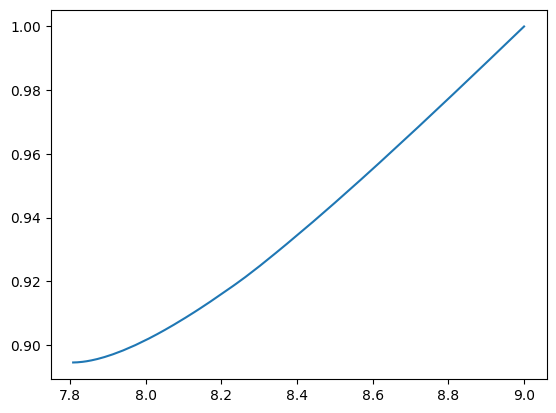

In [25]:
plt.plot(sol.ys[:,0], sol.ys[:,1])

Text(0, 0.5, '$e$')

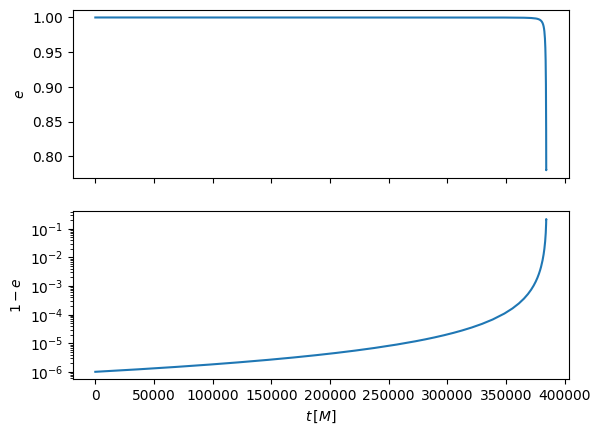

In [83]:
fig, ax = plt.subplots(nrows=2, sharex=True)
ax[1].semilogy(sol.ts, 1 - sol.ys[:,1])
ax[0].plot(sol.ts, sol.ys[:,1])
ax[1].set_xlabel("$t \\, [M]$")
ax[1].set_ylabel(r"$1 - e$")
ax[0].set_ylabel(r"$e$")

In [79]:
N = 100
key = jax.random.PRNGKey(0)
m1s = jax.random.uniform(key, (N,), minval=1e5, maxval=1e7)
subkey, key = jax.random.split(key)
m2s = jax.random.uniform(key, (N,), minval=1e5, maxval=1e7)
subkey, key = jax.random.split(key)
p0s = jax.random.uniform(key, (N,), minval=8.1, maxval=16.0)
subkey, key = jax.random.split(key)
e0s = jax.random.uniform(key, (N,), minval=0.1, maxval=1.0 - 1e-6)
subkey, key = jax.random.split(key)
Phi_phi0s = jax.random.uniform(key, (N,), minval=0.0, maxval=2*jnp.pi)
subkey, key = jax.random.split(key)
Phi_r0s = jax.random.uniform(key, (N,), minval=0.0, maxval=2*jnp.pi)

In [85]:
solutions = multi_traj(
    m1s,
    m2s,
    p0s,
    e0s,
    Phi_phi0s,
    Phi_r0s,
    10
)

def foo():
    return multi_traj(
    m1s,
    m2s,
    p0s,
    e0s,
    Phi_phi0s,
    Phi_r0s,
    10
    )


In [81]:
%timeit foo()

105 ms ± 3 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


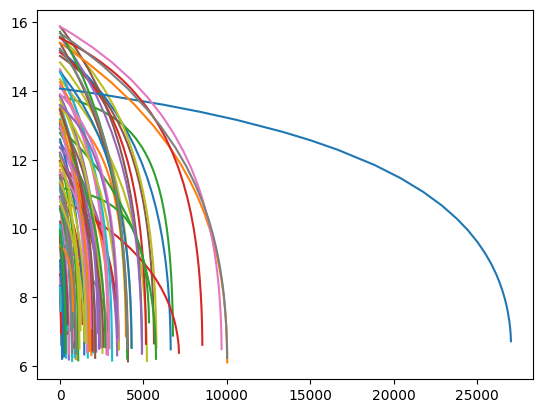

In [86]:
plt.plot(solutions.ts.T, solutions.ys[:,:,0].T)